# Sport Recife 2026 — Análise de Escalações por Fase

Investiga as possíveis causas da deterioração do xG ao longo das fases:
- Rotação e continuidade de jogadores
- Formações utilizadas
- Rating médio dos titulares

In [1]:
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

RESULTS_PATH = Path('../data/processed/2026/sport/sport_2026_results.csv')
STATS_PATH   = Path('../data/processed/2026/sport/sport_2026_team_match_stats.csv')
PLAYERS_PATH = Path('../data/processed/2026/players/sport_2026_player_match_stats.csv')
OUTPUT_DIR   = Path('../data/processed/2026/sport')

TEAM_NAME        = 'Sport Recife'
FASE1_N_JOGOS    = 3
SERIE_B_DEBUT_TS = pd.Timestamp('2026-03-21T23:30:00', tz='UTC')

FASE_LABELS = {
    1: 'Fase 1\nSub20',
    2: 'Fase 2\nPré-Série B',
    3: 'Fase 3\nMárcio Goiano',
}
FASE_COLORS = {1: '#FDE68A', 2: '#BAE6FD', 3: '#BBF7D0'}
FASE_COLORS_DARK = {1: '#D97706', 2: '#0369A1', 3: '#047857'}

In [2]:
# ── Carrega e prepara dados ───────────────────────────────────────────────────
results = pd.read_csv(RESULTS_PATH)
results['match_date_utc'] = pd.to_datetime(results['match_date_utc'], utc=True)
results = results.sort_values('match_date_utc').reset_index(drop=True)
results['jogo_num'] = range(1, len(results) + 1)

def assign_phase(row):
    if row['jogo_num'] <= FASE1_N_JOGOS:
        return 1
    elif row['match_date_utc'] <= SERIE_B_DEBUT_TS:
        return 2
    else:
        return 3

results['fase'] = results.apply(assign_phase, axis=1)
results['opponent'] = results.apply(
    lambda r: r['away_team'] if r['home_team'] == TEAM_NAME else r['home_team'], axis=1
)
results['label'] = results['jogo_num'].astype(str) + '. ' + results['opponent'].str.split().str[0]

# ── Team match stats (xG) ─────────────────────────────────────────────────────
team_stats = pd.read_csv(STATS_PATH)
sport_xg = (
    team_stats.loc[team_stats['team_name'].eq(TEAM_NAME)]
    .drop_duplicates(subset='source_url', keep='first')
    [['source_url', 'expected_goals', 'possession', 'shots_total', 'shots_on_target']]
    .rename(columns={'expected_goals': 'xg_for'})
)

results = results.merge(sport_xg, on='source_url', how='left')

# ── Player stats ──────────────────────────────────────────────────────────────
players_raw = pd.read_csv(PLAYERS_PATH)
sport_players = players_raw.loc[players_raw['team_name'].eq(TEAM_NAME)].copy()

# Merge 4-chave: match_code + home_team + away_team + competition
game_meta = results[['match_id', 'home_team', 'away_team', 'competition_name', 'jogo_num', 'fase', 'label']].copy()
sport_players = sport_players.merge(
    game_meta,
    left_on=['match_code', 'home_team', 'away_team', 'competition'],
    right_on=['match_id', 'home_team', 'away_team', 'competition_name'],
    how='left'
)

print(f'Jogos no results: {len(results)}')
print(f'Jogos com player data: {sport_players["jogo_num"].nunique()}')
print(f'Jogos SEM player data: {set(results["jogo_num"]) - set(sport_players["jogo_num"].dropna())}')

Jogos no results: 19
Jogos com player data: 19
Jogos SEM player data: set()


In [3]:
# ── Formações por jogo ────────────────────────────────────────────────────────
starters = sport_players.loc[~sport_players['is_substitute'] & sport_players['jogo_num'].notna()].copy()

def formation_string(group):
    pos = group['position'].value_counts()
    d = pos.get('D', 0)
    m = pos.get('M', 0)
    f = pos.get('F', 0)
    return f'{d}-{m}-{f}'

formations = (
    starters.groupby('jogo_num')
    .apply(formation_string)
    .reset_index(name='formation')
)

results = results.merge(formations, on='jogo_num', how='left')
print(results[['jogo_num', 'fase', 'label', 'formation', 'xg_for']].to_string(index=False))

 jogo_num  fase          label formation  xg_for
        1     1          1. AD     4-3-3    1.74
        2     1       2. Retrô     4-3-3     NaN
        3     1     3. Náutico     4-4-2    3.08
        4     2     4. Decisão     4-4-2    3.02
        5     2   5. Acadêmica     4-4-2    2.75
        6     2     6. Maguary     4-5-1    1.62
        7     2       7. Santa     4-5-1    2.41
        8     2       8. Retrô     4-5-1     NaN
        9     2       9. Retrô     4-5-1     NaN
       10     2    10. Náutico     4-5-1    0.69
       11     2 11. Desportiva     4-5-1    1.87
       12     2    12. Náutico     4-5-1    0.69
       13     2   13. Anápolis     2-7-1    1.07
       14     2   14. Athletic     4-5-1    0.81
       15     2     15. Cuiabá     3-4-3    0.92
       16     3 16. Jacuipense     4-3-3    0.51
       17     3        17. ABC     4-3-3    1.02
       18     3       18. Vila     3-4-3    0.68
       19     3   19. Londrina     4-3-3    2.23


C:\Users\compesa\AppData\Local\Temp\ipykernel_18132\1909642838.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(formation_string)


In [4]:
# ── Rotação: mudanças no XI titular entre jogos consecutivos ──────────────────
game_starters = (
    starters.groupby('jogo_num')['player_name']
    .apply(set)
    .reset_index(name='starters_set')
    .sort_values('jogo_num')
)

rotations = []
for i in range(1, len(game_starters)):
    prev = game_starters.iloc[i - 1]
    curr = game_starters.iloc[i]
    changes = len(curr['starters_set'] - prev['starters_set'])
    rotations.append({'jogo_num': curr['jogo_num'], 'changes_vs_prev': changes})

rotation_df = pd.DataFrame(rotations)
results = results.merge(rotation_df, on='jogo_num', how='left')

# ── Rating médio dos titulares por jogo ───────────────────────────────────────
avg_rating = (
    starters.groupby('jogo_num')['rating']
    .mean()
    .reset_index(name='avg_rating')
)
results = results.merge(avg_rating, on='jogo_num', how='left')
print(results[['jogo_num','fase','label','formation','changes_vs_prev','avg_rating','xg_for']].to_string(index=False))

 jogo_num  fase          label formation  changes_vs_prev  avg_rating  xg_for
        1     1          1. AD     4-3-3              NaN        6.75    1.74
        2     1       2. Retrô     4-3-3             0.00        7.20     NaN
        3     1     3. Náutico     4-4-2             0.00        6.37    3.08
        4     2     4. Decisão     4-4-2            10.00        7.40    3.02
        5     2   5. Acadêmica     4-4-2             0.00        7.34    2.75
        6     2     6. Maguary     4-5-1             1.00        6.90    1.62
        7     2       7. Santa     4-5-1             2.00        7.07    2.41
        8     2       8. Retrô     4-5-1             3.00        7.15     NaN
        9     2       9. Retrô     4-5-1             2.00        6.76     NaN
       10     2    10. Náutico     4-5-1             6.00        6.82    0.69
       11     2 11. Desportiva     4-5-1            10.00         NaN    1.87
       12     2    12. Náutico     4-5-1             6.00       

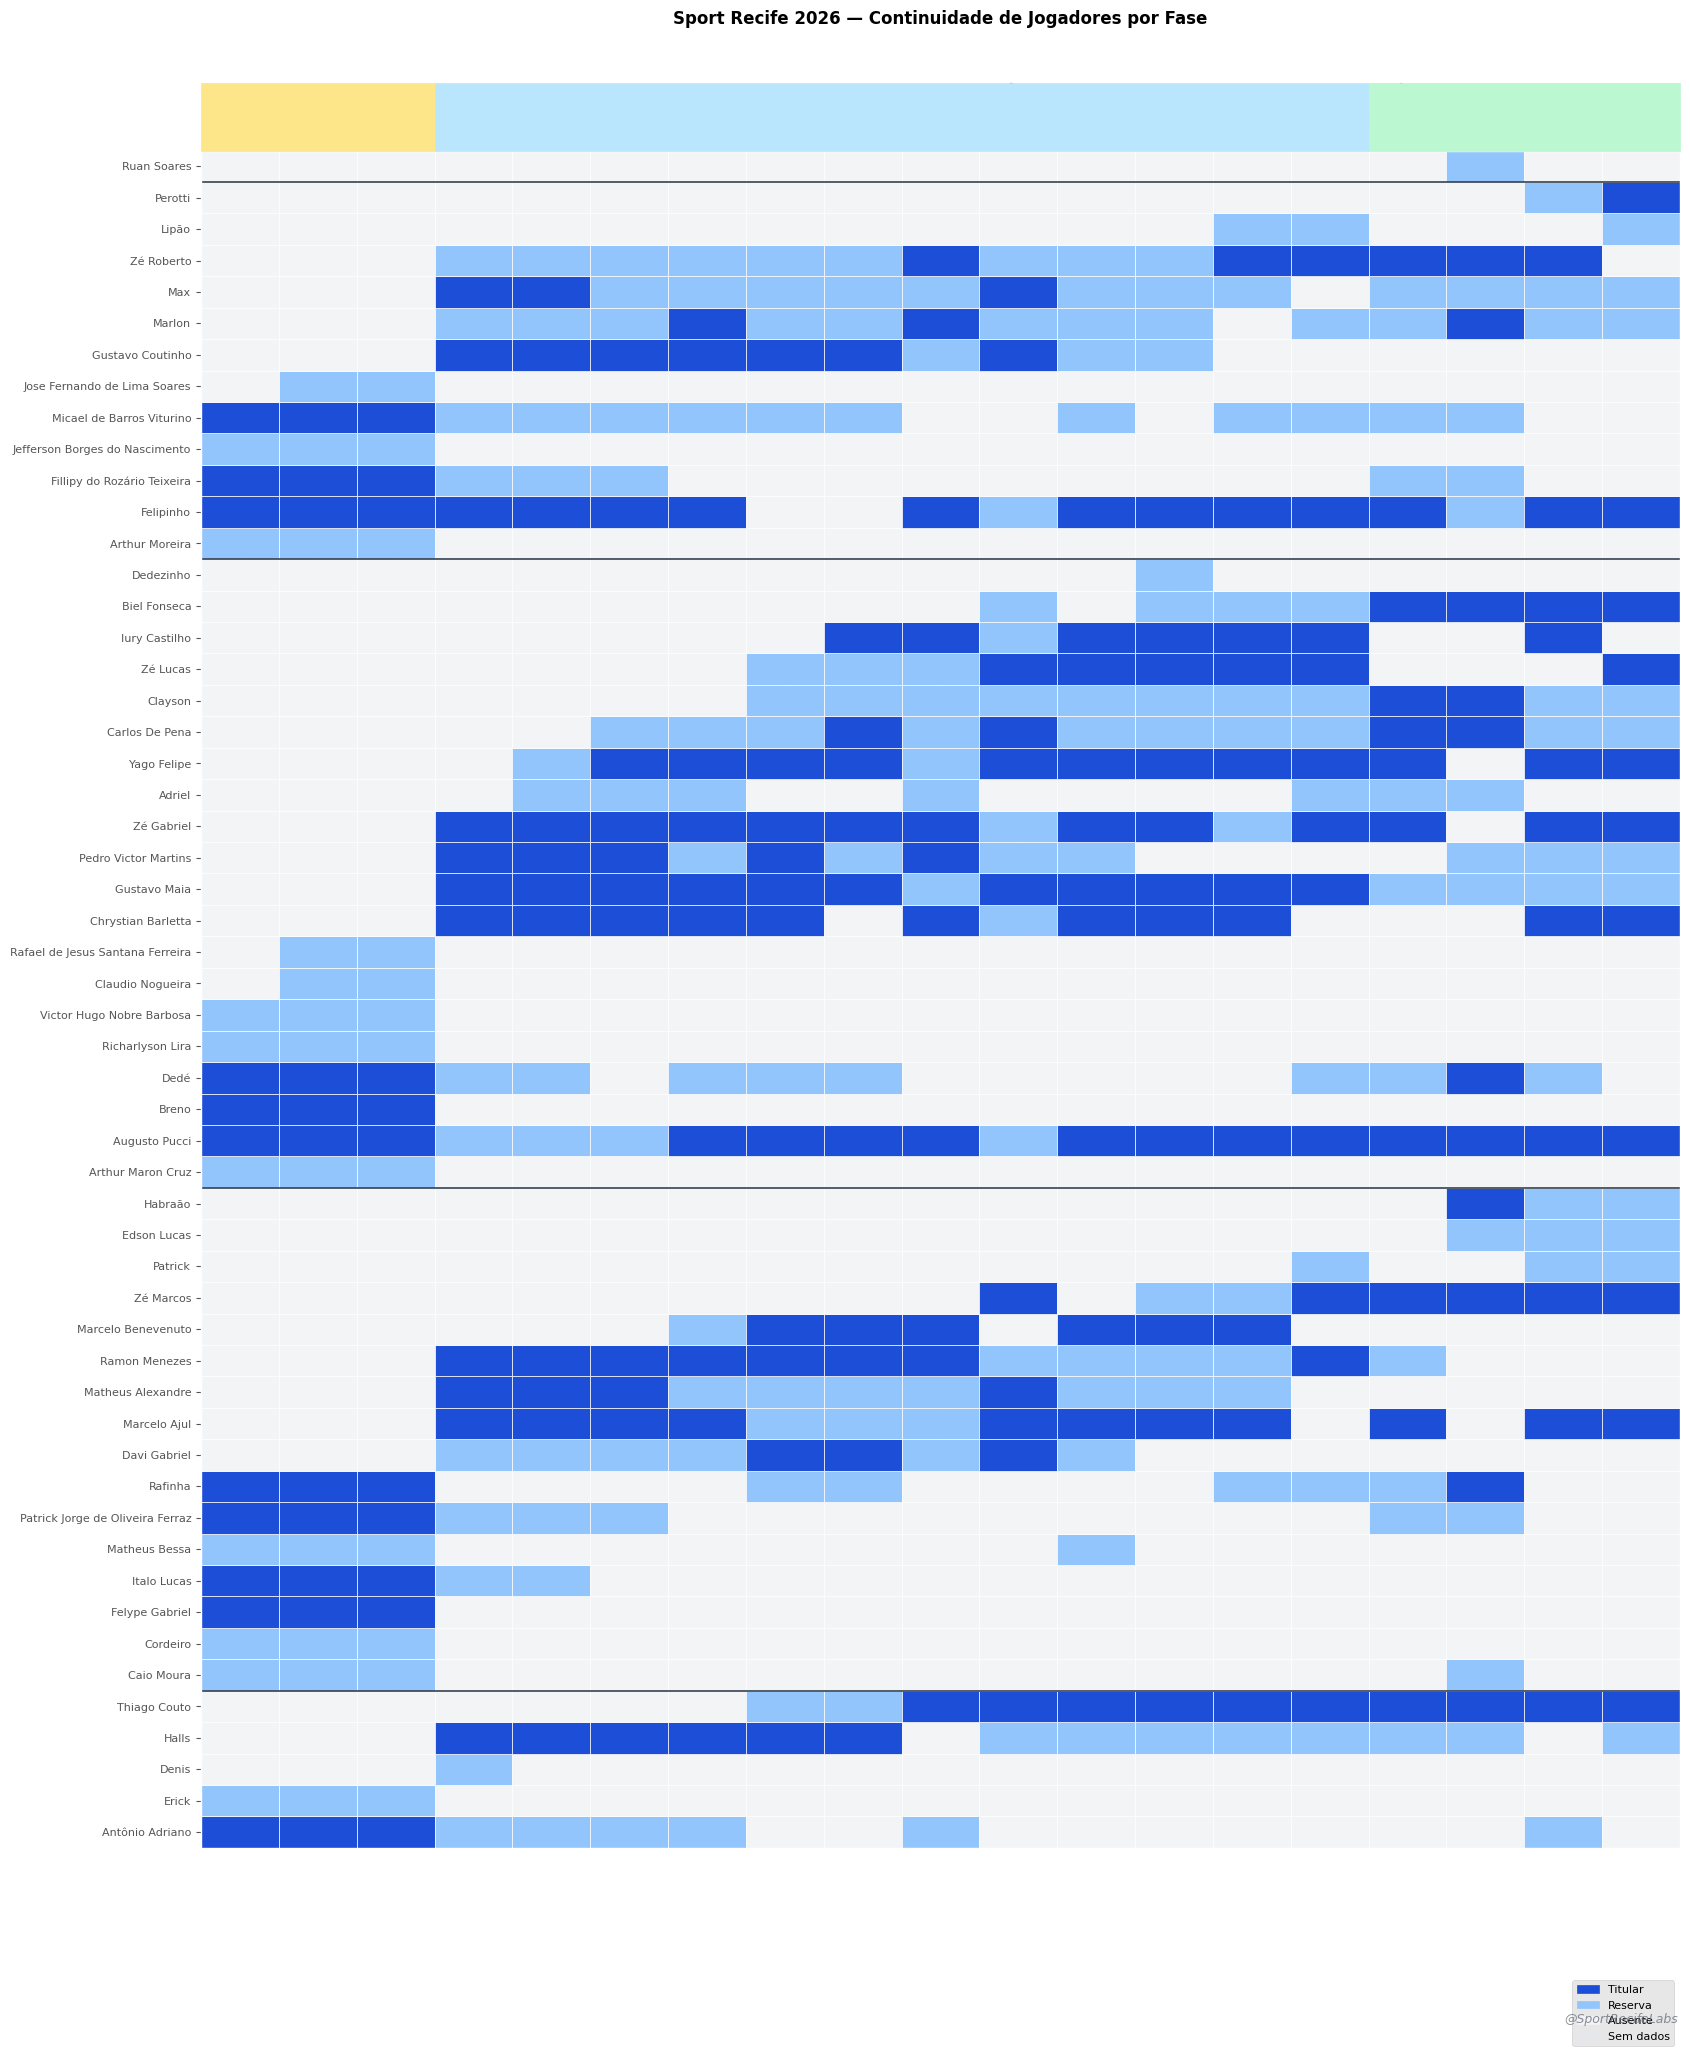

Salvo em ..\data\processed\2026\sport\sport_2026_continuidade_jogadores.png


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# GRÁFICO 1 — Heatmap de continuidade de jogadores
# ══════════════════════════════════════════════════════════════════════════════

# Monta pivot: linhas = jogadores, colunas = jogo_num
# Valor: 2=titular, 1=reserva, 0=ausente
all_players_ordered = (
    sport_players.loc[sport_players['jogo_num'].notna()]
    .assign(role=lambda df: df['is_substitute'].map({False: 2, True: 1}))
)

pivot = (
    all_players_ordered
    .pivot_table(index='player_name', columns='jogo_num', values='role', aggfunc='max')
    .fillna(0)
)
pivot.columns = pivot.columns.astype(int)

# Ordena jogadores: por posição e por primeiro jogo que apareceu
pos_order = sport_players.loc[
    sport_players['jogo_num'].notna(),
    ['player_name', 'position']
].drop_duplicates('player_name').set_index('player_name')['position']

pos_rank = {'G': 0, 'D': 1, 'M': 2, 'F': 3}
first_app = all_players_ordered.groupby('player_name')['jogo_num'].min()

sort_key = pd.DataFrame({
    'pos_rank': pos_order.map(pos_rank),
    'first_app': first_app
}).loc[pivot.index]
pivot = pivot.loc[sort_key.sort_values(['pos_rank', 'first_app']).index]

# Monta colunas para jogos que não têm player data (aparece como coluna ausente)
all_games = sorted(results['jogo_num'].unique())
for g in all_games:
    if g not in pivot.columns:
        pivot[g] = np.nan
pivot = pivot[sorted(pivot.columns)]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(17, max(8, len(pivot) * 0.38)))

cmap_vals = {0: '#F3F4F6', 1: '#93C5FD', 2: '#1D4ED8'}  # ausente / reserva / titular
cell_h, cell_w = 1.0, 1.0

for row_i, player in enumerate(pivot.index):
    for col_j, game in enumerate(sorted(pivot.columns)):
        val = pivot.loc[player, game]
        if np.isnan(val):
            color = '#E5E7EB'  # sem dados
        else:
            color = cmap_vals[int(val)]
        rect = plt.Rectangle((col_j, row_i), cell_w, cell_h,
                               facecolor=color, edgecolor='white', linewidth=0.5)
        ax.add_patch(rect)

# Faixas de fase por coluna
for col_j, game in enumerate(sorted(pivot.columns)):
    fase_id = results.loc[results['jogo_num'] == game, 'fase']
    if not fase_id.empty:
        ax.axvspan(col_j, col_j + cell_w, ymin=0, ymax=1,
                   color=FASE_COLORS[fase_id.values[0]], alpha=0.08, zorder=0)

# Linha separadora de posição
if 'pos_order' in dir():
    current_pos = None
    for row_i, player in enumerate(pivot.index):
        p = pos_order.get(player, None)
        if p != current_pos and row_i > 0:
            ax.axhline(row_i, color='#374151', linewidth=1.2, linestyle='-')
        current_pos = p

# Eixos
ax.set_xlim(0, len(pivot.columns))
ax.set_ylim(0, len(pivot))
ax.set_yticks(np.arange(len(pivot)) + 0.5)
ax.set_yticklabels(pivot.index, fontsize=8)
ax.set_xticks(np.arange(len(all_games)) + 0.5)
col_labels = [
    results.loc[results['jogo_num'] == g, 'label'].values[0]
    if g in results['jogo_num'].values else str(g)
    for g in sorted(pivot.columns)
]
ax.set_xticklabels(col_labels, rotation=45, ha='right', fontsize=7.5)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', top=True, bottom=False)

# Rótulos de fase
fase_groups = results.groupby('fase')['jogo_num']
for fase_id, group in fase_groups:
    games_in_phase = [g for g in sorted(group.values) if g in pivot.columns]
    if not games_in_phase:
        continue
    col_positions = [sorted(pivot.columns).index(g) for g in games_in_phase]
    mid = (min(col_positions) + max(col_positions) + 1) / 2
    ax.text(mid, len(pivot) + 0.4, FASE_LABELS[fase_id].replace('\n', ' '),
            ha='center', va='bottom', fontsize=8.5, fontweight='bold',
            color=FASE_COLORS_DARK[fase_id])
    ax.axvspan(min(col_positions), max(col_positions) + 1,
               ymin=1.0, ymax=1.04, color=FASE_COLORS[fase_id],
               clip_on=False, zorder=5)

# Legenda
legend_handles = [
    mpatches.Patch(color='#1D4ED8', label='Titular'),
    mpatches.Patch(color='#93C5FD', label='Reserva'),
    mpatches.Patch(color='#F3F4F6', label='Ausente'),
    mpatches.Patch(color='#E5E7EB', label='Sem dados'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=8,
          framealpha=0.9, bbox_to_anchor=(1.0, -0.12))

ax.set_title('Sport Recife 2026 — Continuidade de Jogadores por Fase',
             fontsize=12, fontweight='bold', pad=40)
fig.text(0.99, 0.01, '@SportRecifeLabs', ha='right', va='bottom',
         fontsize=9, color='#6B7280', alpha=0.8, style='italic')

plt.tight_layout()
out = OUTPUT_DIR / 'sport_2026_continuidade_jogadores.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Salvo em {out}')

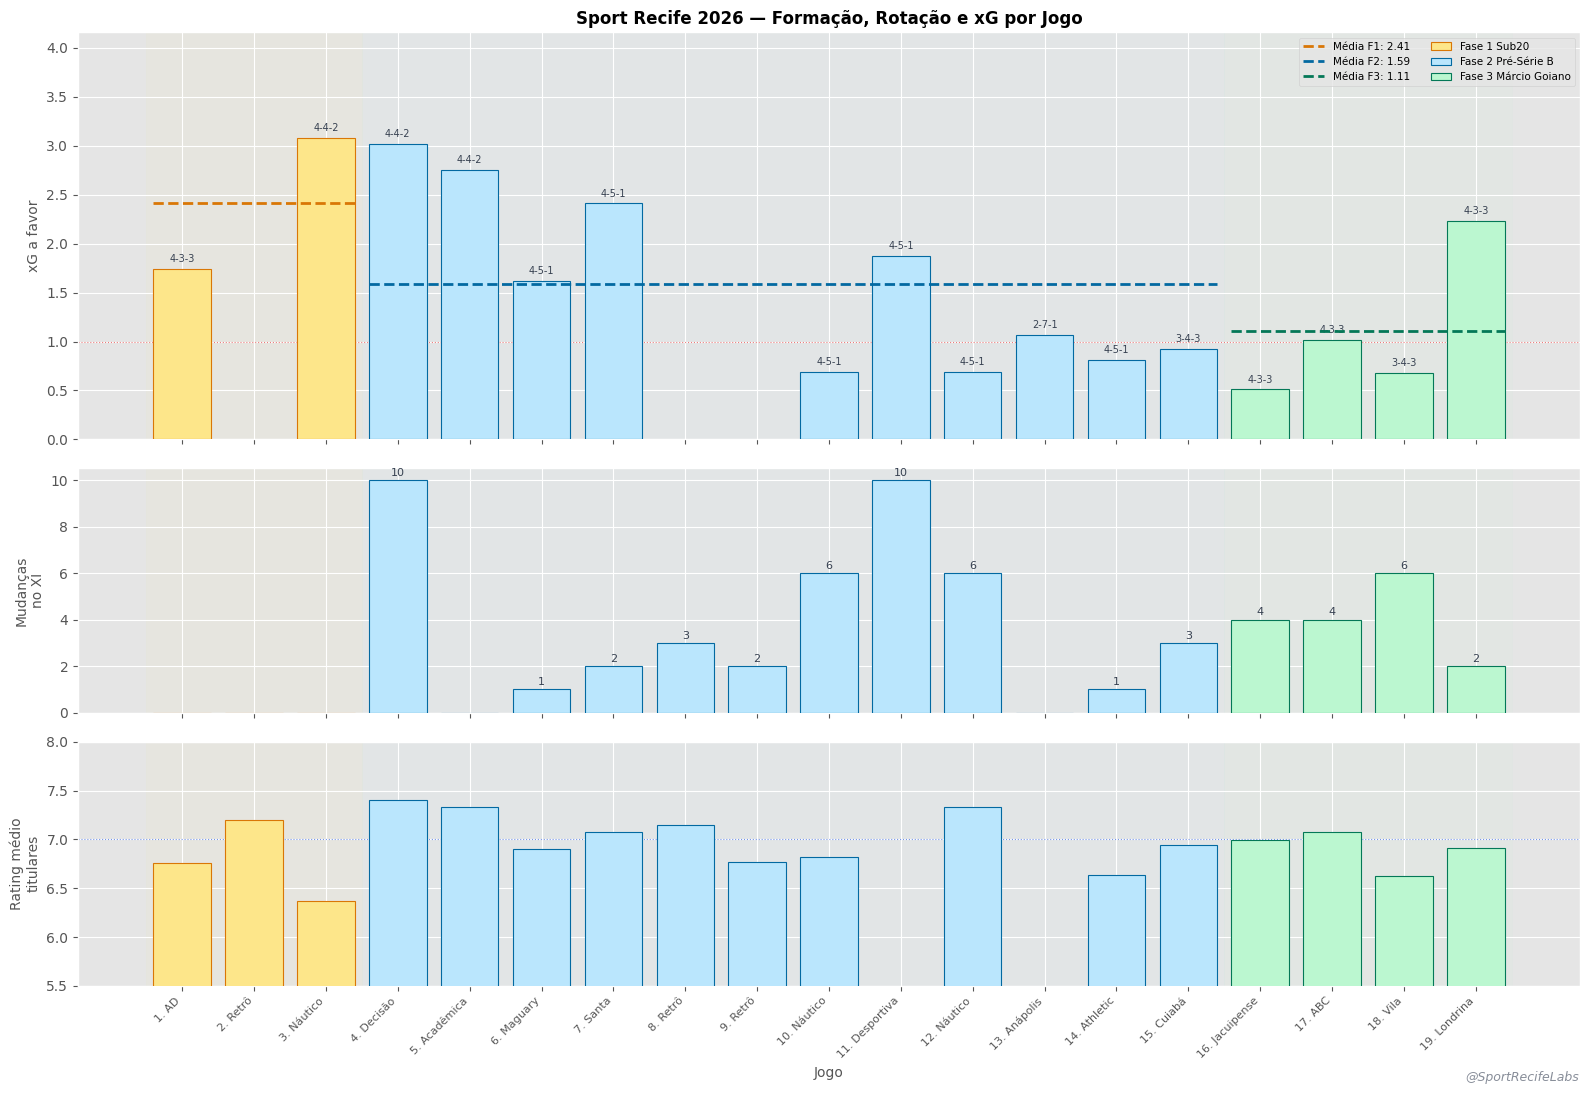

Salvo em ..\data\processed\2026\sport\sport_2026_formacao_rotacao_xg.png


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# GRÁFICO 2 — Formação, rotação e xG por jogo
# ══════════════════════════════════════════════════════════════════════════════

df = results.dropna(subset=['jogo_num']).sort_values('jogo_num').copy()
games_with_data = df.loc[df['formation'].notna()]

fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1.2, 1.2]})

x = df['jogo_num'].values
x_labels = df['label'].values
fase_vals = df['fase'].values

# ── Subplot 1: xG pró por jogo com formação anotada ─────────────────────────
ax1 = axes[0]
for i, fase_id in enumerate(sorted(df['fase'].unique())):
    mask = df['fase'] == fase_id
    ax1.bar(df.loc[mask, 'jogo_num'], df.loc[mask, 'xg_for'],
            color=FASE_COLORS[fase_id], edgecolor=FASE_COLORS_DARK[fase_id],
            linewidth=0.8, label=FASE_LABELS[fase_id].replace('\n', ' '), zorder=3)

# Média por fase
for fase_id in sorted(df['fase'].unique()):
    sub = df.loc[df['fase'] == fase_id, 'xg_for'].dropna()
    if sub.empty:
        continue
    game_ids = df.loc[df['fase'] == fase_id, 'jogo_num'].values
    ax1.hlines(sub.mean(), game_ids.min() - 0.4, game_ids.max() + 0.4,
               color=FASE_COLORS_DARK[fase_id], linewidth=2,
               linestyle='--', zorder=4,
               label=f'Média F{fase_id}: {sub.mean():.2f}')

# Anotação: formação
for _, row in games_with_data.iterrows():
    if pd.notna(row.get('xg_for')):
        ax1.text(row['jogo_num'], row['xg_for'] + 0.05, row['formation'],
                 ha='center', va='bottom', fontsize=7, color='#374151')

ax1.set_ylabel('xG a favor', fontsize=10)
ax1.set_ylim(0, df['xg_for'].max() * 1.35)
ax1.legend(fontsize=7.5, loc='upper right', ncol=2)
ax1.set_title('Sport Recife 2026 — Formação, Rotação e xG por Jogo',
              fontsize=12, fontweight='bold')
ax1.axhline(1.0, color='#DC2626', linewidth=0.8, linestyle=':', alpha=0.6)

# ── Subplot 2: Mudanças no XI vs jogo anterior ──────────────────────────────
ax2 = axes[1]
for fase_id in sorted(df['fase'].unique()):
    mask = df['fase'] == fase_id
    ax2.bar(df.loc[mask, 'jogo_num'],
            df.loc[mask, 'changes_vs_prev'].fillna(0),
            color=FASE_COLORS[fase_id], edgecolor=FASE_COLORS_DARK[fase_id],
            linewidth=0.8, zorder=3)

ax2.set_ylabel('Mudanças\nno XI', fontsize=10)
ax2.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax2.axhline(0, color='gray', linewidth=0.5)

# Anotação: número de mudanças
for _, row in df.iterrows():
    val = row.get('changes_vs_prev')
    if pd.notna(val) and val > 0:
        ax2.text(row['jogo_num'], val + 0.1, str(int(val)),
                 ha='center', va='bottom', fontsize=8, color='#374151')

# ── Subplot 3: Rating médio dos titulares ────────────────────────────────────
ax3 = axes[2]
for fase_id in sorted(df['fase'].unique()):
    mask = df['fase'] == fase_id
    ax3.bar(df.loc[mask, 'jogo_num'],
            df.loc[mask, 'avg_rating'],
            color=FASE_COLORS[fase_id], edgecolor=FASE_COLORS_DARK[fase_id],
            linewidth=0.8, zorder=3)

ax3.set_ylabel('Rating médio\ntitulares', fontsize=10)
ax3.set_ylim(5.5, 8.0)
ax3.axhline(7.0, color='#1D4ED8', linewidth=0.8, linestyle=':', alpha=0.6)

# Eixo X compartilhado
ax3.set_xticks(df['jogo_num'].values)
ax3.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
ax3.set_xlabel('Jogo', fontsize=10)

# Faixas de fase nos 3 subplots
for ax in axes:
    for fase_id in sorted(df['fase'].unique()):
        sub = df.loc[df['fase'] == fase_id, 'jogo_num']
        ax.axvspan(sub.min() - 0.5, sub.max() + 0.5,
                   color=FASE_COLORS[fase_id], alpha=0.06, zorder=0)

fig.text(0.99, 0.01, '@SportRecifeLabs', ha='right', va='bottom',
         fontsize=9, color='#6B7280', alpha=0.8, style='italic')

plt.tight_layout()
out2 = OUTPUT_DIR / 'sport_2026_formacao_rotacao_xg.png'
plt.savefig(out2, dpi=150, bbox_inches='tight')
plt.show()
print(f'Salvo em {out2}')

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# TABELA RESUMO — Estatísticas médias por fase
# ══════════════════════════════════════════════════════════════════════════════

summary = (
    results.groupby('fase')
    .agg(
        jogos=('jogo_num', 'count'),
        xg_medio=('xg_for', 'mean'),
        posse_media=('possession', 'mean'),
        chutes_medio=('shots_total', 'mean'),
        chutes_no_alvo=('shots_on_target', 'mean'),
        rating_medio=('avg_rating', 'mean'),
        rotacao_media=('changes_vs_prev', 'mean'),
    )
    .rename(index=lambda f: FASE_LABELS[f].replace('\n', ' '))
)

summary.columns = ['Jogos', 'xG médio', 'Posse %', 'Finalizações', 'No alvo', 'Rating médio', 'Rotação média']
print('=== Resumo por fase ===')
display(summary.round(2))

# Jogadores mais usados por fase
print('\n=== Top 5 jogadores por aparições como titular, por fase ===')
for fase_id in [1, 2, 3]:
    top = (
        starters.loc[starters['fase'] == fase_id, 'player_name']
        .value_counts()
        .head(5)
    )
    print(f'\nFase {fase_id} — {FASE_LABELS[fase_id].replace(chr(10), " ")}:')
    for name, count in top.items():
        print(f'  {name}: {count}x')

=== Resumo por fase ===


,Jogos,xG médio,Posse %,Finalizações,No alvo,Rating médio,Rotação média
fase,,,,,,,
Fase 1 Sub20,3,2.41,50.50,14.50,5.50,6.78,0.00
Fase 2 Pré-Série B,12,1.58,59.11,14.62,4.56,7.03,3.67
Fase 3 Márcio Goiano,4,1.11,52.50,11.50,5.00,6.90,4.00



=== Top 5 jogadores por aparições como titular, por fase ===

Fase 1 — Fase 1 Sub20:
  Antônio Adriano: 3x
  Italo Lucas: 3x
  Patrick Jorge de Oliveira Ferraz: 3x
  Felype Gabriel: 3x
  Rafinha: 3x

Fase 2 — Fase 2 Pré-Série B:
  Gustavo Maia: 11x
  Zé Gabriel: 10x
  Felipinho: 9x
  Yago Felipe: 9x
  Chrystian Barletta: 9x

Fase 3 — Fase 3 Márcio Goiano:
  Thiago Couto: 4x
  Augusto Pucci: 4x
  Zé Marcos: 4x
  Biel Fonseca: 4x
  Marcelo Ajul: 3x
